# The Photoelectric Effect

In this experiment, you will investigate the photoelectric effect as a proof of the particle nature of light, and you will discover a mysterious physical constant. You will also gain experience manipulating spreadsheet data with Python, and with any luck you’ll never have to use Excel again.

As in the previous X-ray diffraction lab, the emphasis of this assignment is not only on generating plots, but on understanding how mathematical and computational models represent physical relationships.

---

**Chemistry Learning Objectives:**
 - C3.1: Apply the photoelectric effect to extract physical constants.
 - C3.2: Explain how the photoelectric effect suggests the existence of photons.
 - C3.3: Interpret the reasonableness of experimental data using physical reasoning.

**Programming Learning Objectives:**
- P3.1: Interpret Python functions as physical models.
- P3.2: Create reusable, modular functions to process and visualize data.
- P3.3: Use `pandas` to manipulate and filter tabular (spreadsheet) data.
- P3.4: Use linear regression with `scipy`.
- P3.5: Use for loops to automate applying functions many times.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import speed_of_light, Planck, e as elementary_charge
from scipy.stats import linregress

# Warmup — Functions and Abstraction

In this notebook, we will use **Python functions** to represent relationships between physical quantities. A Python function is a rule that takes one or more **inputs** and returns an **output**. In the context of scientific computing, the most important point is that a function is not just code: it is a *model* for a relationship we believe is well-defined.

A function has three parts:

1. **Inputs (arguments):** the quantities you provide to the function.
2. **The rule:** the operations that transform inputs into an output.
3. **Output (return value):** the quantity the function produces.

For example, if `lam_nm` is a wavelength in nanometers, a conversion function might map

$$
\lambda \ \mapsto\ f
$$

meaning: “given a wavelength, return the corresponding frequency.” In Python, this looks like a function that takes a number (or an array of numbers) and returns a number (or array).

In this lab, we will repeatedly use functions to carry out transformations that mirror the analysis steps you perform conceptually:

1. **Convert light properties**
   $$
   \lambda \ \mapsto\ f, \qquad f \ \mapsto\ E_{\text{photon}}
   $$
2. **Extract a stopping potential from an I–V dataset**
   $$
   \{(V, I)\} \ \mapsto\ V_0
   $$
3. **Use a linear model to extract constants**
   $$
   f \ \mapsto\ V_0 \quad \Rightarrow \quad \text{slope and intercept}
   $$


## Warmup Coding Activity

A major advantage of functions is that they allow you to apply the *same* rule consistently across many datasets. For example, once you have a reliable function for extracting $V_0$ from a current–voltage curve, you can apply it to every wavelength without repeating manual steps. This reduces errors and makes your analysis reproducible.

Finally, throughout this notebook you should be able to answer the following about any function you use:

1. What are the **inputs**, including their **units**?
2. What is the **output**, including its **units**?
3. What physical relationship or modeling assumption does the function encode?
4. How could you check that the output is reasonable (order of magnitude, limiting behavior, trends)?

Let's get some practice with this!

### W.A — Converting Wavelength to Frequency

`5 points`


The frequency $f$ of light is related to its wavelength $\lambda$ by the speed of light $c$:

$$
f = \frac{c}{\lambda}
$$

Mind your units! Typically, wavelengths are specified in **nanometers** and frequency is expressed in **hertz ($s^{-1}$)**. 

In [35]:
from scipy.constants import speed_of_light  # in m/s

def wavelength_nm_to_thz(wavelength):
    """
    Convert a wavelength in nanometers to frequency in terahertz.
    Parameters
        wavelength : (nm) float or array-like
    Returns
        frequency : (THz) float or array-like
    """
    frequency_hz = speed_of_light / (wavelength)
    frequency_thz = # YOUR CODE HERE: add the appropriate conversion factor to make the output THz!
    return frequency_thz

# Test: 700 nm light should be about 428 THz
print(wavelength_nm_to_thz(700))

SyntaxError: invalid syntax (4026153553.py, line 12)

### W.B — Photon Energy as a Function of Frequency

`2 points`

Once the frequency of the incident light is known, the energy of an individual photon is given by

$$
E = h f
$$

where $h$ is Planck’s constant. Although Planck’s constant will later be *determined experimentally* in this lab, it is still useful at this stage to compute photon energies in order to compare different wavelengths qualitatively.

Write a function that takes frequency in terahertz (THz) and returns photon energy in joules (J).

In [ ]:
from scipy.constants import Planck  # h in J·s

def frequency_thz_to_energy_joule(frequency_thz):
    """
    Convert frequency (THz) to photon energy (J).

    Parameters
    ----------
    frequency_thz : float or array-like
        Frequency in terahertz (THz).

    Returns
    -------
    energy_joule : float or array-like
        Photon energy in joules (J).
    """
    # convert frequency to Hz with appropriate conversion factor (1e12)
    # 
    return energy_joule

# Quick checks
print(frequency_thz_to_energy_joule(822))   # order of magnitude ~ 1e-19 J
print(frequency_thz_to_energy_joule(np.array([822, 740])))

5.4466296633e-19
[5.44662966e-19 4.90329191e-19]


### W.C — Light Properties Table

`2 points`

In the rest of the notebook you will repeatedly need wavelength, frequency, and photon energy for the same set of filters. Rather than recomputing these values manually each time, write a function that takes a list/array of wavelengths (nm) and returns a table containing:

- wavelength (nm)
- frequency (THz)
- photon energy (J)

Your function should call your functions from Parts W.A and W.B.

In [ ]:
def make_light_properties_table(wavelengths_nm):
    """
    Build a table of wavelength (nm), frequency (THz), and photon energy (J).
    Parameters
        wavelengths_nm : array-like
    Returns
        table : pandas.DataFrame
            Columns: wavelength_nm, frequency_thz, energy_joule
    """
    frequency_thz = # your code here!
    energy_joule = # your code here!
    table = pd.DataFrame({ # this is how we make DataFrames. More on these later!
        'wavelength_nm': wavelengths_nm,
        'frequency_thz': frequency_thz,
        'energy_joule': energy_joule
    })
    return table

filters_nm = [200, 250, 300, 350]
make_light_properties_table(filters_nm)

SyntaxError: invalid syntax (1658168326.py, line 10)

## Question W

`10 points`

- P3.1: Interpret Python functions as physical models.
- P3.2: Use functions to transform experimental data.

a) In this experiment, give one example of a function that maps a *measured* quantity to a *derived* quantity.

b) Why is it useful to package a repeated analysis step (such as determining $V_0$) into a function instead of doing it manually for each wavelength?

c) Suppose a function returns a stopping potential with the wrong sign. What is one physical check you could use to notice that something is inconsistent?

---

# Part 1 — The Experiment and the Data

## 1.1 — Experimental Measurements

The photoelectric effect was one of the pivotal proofs of quantum mechanics and led to Albert Einstein’s discovery of the photon. How can such a simple experiment give us that much information?

In the photoelectric effect experiment, we shine monochromatic light on a metal cathode inside a vacuum photocell. The light can excite electrons in the metal and cause them to be emitted from the surface. The emitted electrons are collected at the anode, resulting in a measurable current.

<figure style="text-align: center;">
  <img src="https://cdn1.byjus.com/wp-content/uploads/2019/09/Experimental-study-of-photoelectric-effect.png"
       width="600">
  <figcaption style="font-size: 0.9em; margin-top: 6px;">
    Image credit: <a href="https://byjus.com/jee/photoelectric-effect/" target="_blank">
    https://byjus.com/jee/photoelectric-effect/
    </a>
  </figcaption>
</figure>

For a fixed wavelength, the applied voltage across the photocell is varied while the resulting current is recorded, producing a current–voltage (I–V) curve (which you will shortly visualize for yourself!)

The applied voltage *resists* the travel of the electrons, so for an electron to complete the circuit, it must have enough kinetic energy to overcome the potential between the anode and cathode. This results in less and less current as we increase the voltage (why?).

So, this experiment is able to give us a measure of how much energy the light is giving to the electrons. But how does this suggest the existence of quantum mechanics? Keep going and find out!

## Coding Activity 1

In this notebook, each set of current–voltage measurements is treated as a dataset associated with a single wavelength of light. From each dataset, the primary quantity we seek to determine is the stopping potential $V_0$. Once the stopping potential has been extracted for several different wavelengths, these values are related to the frequency of the incident light through Einstein’s photoelectric equation.

This analysis involves a sequence of transformations between physical quantities: wavelength is converted to frequency, frequency is related to photon energy, and the stopping potential is used to determine fundamental constants such as Planck’s constant and the work function of the cathode material. Because each step maps one set of inputs to a well-defined output, the photoelectric effect provides a natural framework for thinking about experimental analysis in terms of functions, both mathematical functions and Python functions, whose purpose is to model physical relationships rather than simply manipulate numbers.

---

In this section, you will use the `pandas` and `NumPy` libraries to extract the stopping potential from current-voltage (I–V) data collected for a calcium cathode at four different wavelengths (200–350 nm in increments of 50 nm).

Each dataset contains measured voltage and corresponding photocurrent values for a fixed wavelength of incident light.

Recall that the stopping potential $V_0$ is defined as the voltage at which the photocurrent becomes zero. Your task is to visualize each I–V curve and extract the stopping potential. Doing this manually would be painful, so we will automate it using *functions*!

The approach for this section is:

1. Load and plot one dataset as a sanity check.
2. Write a small function to perform linear regression.
3. Observe that the regression on raw data looks terrible — motivating data filtering.
4. Filter the data, redo the regression, and extract $V_0$.

### Part 1A — Loading and Plotting Data with `pandas` and `matplotlib`

`5 points`

Select one dataset (for example, `ca_200nm_25intens.csv`) and generate a scatter plot of:

- Current (µA) on the y-axis
- Voltage (V) on the x-axis

Your plot should include clearly labeled axes with units and a descriptive title.

Use this as a **sanity check**: does the trend in the data match the expected physical behavior? At what approximate voltage does the current cross zero?

In [6]:
# Load one dataset with pandas
ca_data = pd.read_csv('data/ca_200nm_25intens.csv')
ca_data.head()

,voltage_V,current_uA
0,1.00,1.0089
1,0.95,0.9975
2,0.90,1.0117
3,0.85,1.0274
4,0.80,0.9958


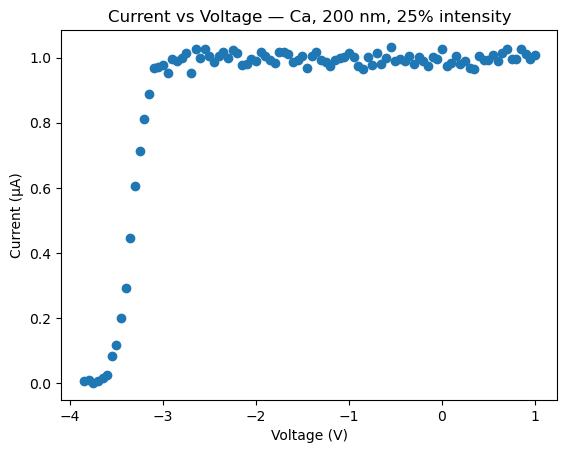

In [7]:
# Scatter plot of current vs voltage
# Useful functions: plt.scatter(x, y), plt.title(), plt.xlabel(), plt.ylabel()
# Use plt.scatter() for experimental data and plt.plot() for regressions.

V = ca_data['voltage_V']
I = ca_data['current_uA']

plt.scatter(V, I)
plt.title('Current vs Voltage \u2014 Ca, 200 nm, 25% intensity')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (\u00b5A)')
plt.show()

### Part 1B — Linear Regression

`5 points`

*[Draft placeholder — needs instructor review]*

Now we want to fit a straight line to our data to find the stopping potential. The stopping potential $V_0$ is the voltage at which the current becomes zero. If the I–V relationship is approximately linear near the cutoff, we can:

1. Fit a line $I = mV + b$ to the data.
2. Solve for where $I = 0$: $V_0 = -b/m$.

**Your task:** Write a function called `linear_fit` that takes arrays `x` and `y`, performs a linear regression using `linregress`, and returns the slope and intercept.

Then, apply your function to the **unfiltered** data and plot the result. Does the fit look good? Why or why not?

In [8]:
def linear_fit(x, y):
    """
    Perform linear regression on x and y data.

    Parameters
    ----------
    x : array-like
        Independent variable.
    y : array-like
        Dependent variable.

    Returns
    -------
    slope : float
    intercept : float
    """
    result = linregress(x, y)
    return result.slope, result.intercept

# Apply to unfiltered data
slope, intercept = linear_fit(V, I)
print(f'slope     = {slope:.4f}')
print(f'intercept = {intercept:.4f}')

slope     = 0.1191
intercept = 1.0569


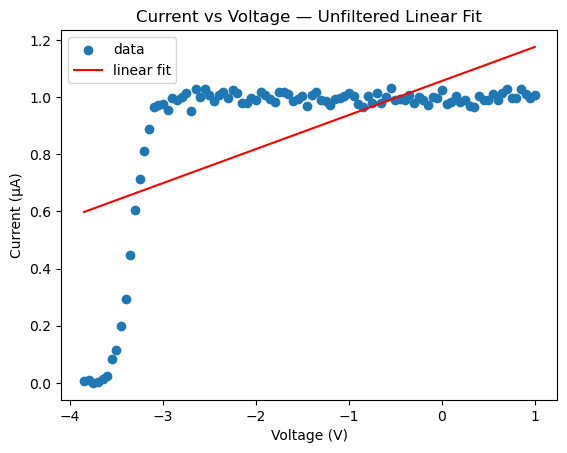

In [9]:
# Plot the (bad) fit over the data
I_fit = slope * V + intercept

plt.scatter(V, I, label='data')
plt.plot(V, I_fit, color='red', label='linear fit')
plt.title('Current vs Voltage \u2014 Unfiltered Linear Fit')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (\u00b5A)')
plt.legend()
plt.show()

### Part 1C — Filtering Tabular Data with `pandas`

`5 points`

Okay, that looks pretty terrible! Clearly this line of best fit cannot be used to get the stopping potential from our dataset. We will need to *filter* our data so that we are only using values from the linear region.

This will require filtering out data from both the zero current and saturation current regions. Fortunately for us, `pandas` makes this very easy to do. An example is provided for filtering out the saturation current region; **your task** will be to filter out the zero current region and re-create the plot.

After filtering, re-apply your `linear_fit` function, plot the result, and extract $V_0 = -b/m$.

In [10]:
# --- Filtering ---
sat_current = max(I)  # the saturation current

# Comparison operators on arrays return arrays of True/False values for filtering
sat_filter = I < (sat_current * 0.9)   # exclude saturation region

# Your turn: filter out the zero-current region.
# Don't use == 0; use a small threshold (e.g. 10% of saturation current).
zero_filter = I > (sat_current * 0.1)

# Combine filters with '&' (both conditions must be True)
total_filter = sat_filter & zero_filter

V_filter = V[total_filter]
I_filter = I[total_filter]

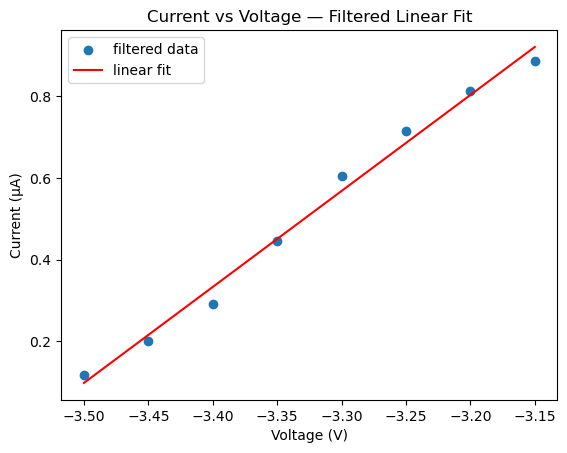

Stopping potential V0 = -3.5416 V


In [11]:
# --- Regression on filtered data ---
slope, intercept = linear_fit(V_filter, I_filter)
I_filter_fit = slope * V_filter + intercept

plt.scatter(V_filter, I_filter, label='filtered data')
plt.plot(V_filter, I_filter_fit, color='red', label='linear fit')
plt.title('Current vs Voltage \u2014 Filtered Linear Fit')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (\u00b5A)')
plt.legend()
plt.show()

# --- Extract V0 ---
V0 = -intercept / slope
print(f'Stopping potential V0 = {V0:.4f} V')

## Question 1

`10 points`

- C3.2: Relate photon properties to electron emission behavior.
- C3.3: Interpret experimental trends using physical reasoning.

a) Why is the stopping potential associated with the maximum kinetic energy of the emitted electrons rather than the average kinetic energy?

b) For a fixed wavelength of light, why does changing the applied voltage affect the measured current but not the energy of individual photons?

c) If two different wavelengths produced the same stopping potential, what would that imply about the energy of the emitted electrons?

d) *[Draft placeholder — needs instructor review]* Based on what you know so far, describe how the photoelectric effect might suggest that light energy is quantized (i.e., comes in discrete packets) rather than being continuous.

---

# Part 2 — Now Make It Automatic

In Part 1, you loaded a single dataset, filtered it, performed a linear regression, and extracted the stopping potential $V_0$. That involved writing several cells of code — and you only analyzed *one* out of sixteen datasets.

What if you had to do this 100 times? Or 10,000?

This is the best thing about Python compared to Excel. In Excel, you would need to repeat every step by hand for each dataset. In Python, doing it once is as good as doing it a million times — if you write a **function**.

The key idea is **abstraction**: you take a sequence of concrete steps that you know work, and you package them into a reusable function. The function hides the details and lets you think at a higher level: “give me the stopping potential for this dataset” instead of “load the file, extract columns, filter, fit, solve.”

In this part, you will:

1. **Collect** your Part 1 code into a reusable `get_V0` function.
2. **Apply** it to all wavelengths at one intensity using a `for` loop.
3. **Extend** to all wavelengths *and* all intensities using a nested `for` loop.

### 2A — Making a Function from Your Loose Code

`5 points`

Write a function called `get_V0` that takes a DataFrame (like `ca_data`) and returns the stopping potential.

**Do NOT write this from scratch!** Copy and paste your working code from Part 1 and organize it into a function. This is exactly what abstraction means: you’ve already done the hard work; now you’re just packaging it.

In [22]:
def get_V0(ca_data):
    """
    Extract the stopping potential V0 from a current-voltage DataFrame.

    Parameters
    ----------
    ca_data : pandas.DataFrame
        Must contain columns 'voltage_V' and 'current_uA'.

    Returns
    -------
    V0 : float
        Stopping potential in volts.
    """
    V = ca_data['voltage_V']
    I = ca_data['current_uA']

    # Filter flat regions at zero and saturation current
    sat_current = max(I)
    sat_filter = I < (sat_current * 0.8)
    zero_filter = I > (sat_current * 0.2)
    total_filter = sat_filter & zero_filter

    V_filter = V[total_filter]
    I_filter = I[total_filter]

    # Perform linear regression
    slope, intercept = linear_fit(V_filter, I_filter)

    # V0 is the voltage where current = 0
    V0 = -intercept / slope
    return V0

In [23]:
# Test: should give the same V0 as Part 1
test_data = pd.read_csv('data/ca_200nm_25intens.csv')
print(f'V0 = {get_V0(test_data):.4f} V')

V0 = -3.5195 V


### 2B — Apply to All Wavelengths at One Intensity

`5 points`

Now apply your `get_V0` function to all four wavelengths at a single intensity (e.g., 100%).

A helper function `get_filename` is provided. Use a `for` loop to iterate through the wavelengths, load each dataset, extract $V_0$, and collect the results.

**Important:** Add a comment on every line of the loop body explaining what that line does.

In [24]:
def get_filename(wavelength, intensity):
    """Build the CSV filename for a given wavelength and intensity."""
    return f'data/ca_{wavelength}nm_{intensity}intens.csv'

wavelengths = [200, 250, 300, 350]
intens = 100

wavelength_data = []
V0_data = []

for wave in wavelengths:
    filename = get_filename(wave, intens)      # build the path to the CSV file
    ca_data = pd.read_csv(filename)            # load the data into a DataFrame
    V0 = get_V0(ca_data)                       # extract the stopping potential
    wavelength_data.append(wave)               # store the wavelength
    V0_data.append(V0)                         # store the V0 value

# Build a DataFrame from the collected lists
results_one_intensity = pd.DataFrame({
    'wavelength (nm)': wavelength_data,
    'V0': V0_data,
})
results_one_intensity

,wavelength (nm),V0
0,200,-3.493575
1,250,-2.265640
2,300,-1.444150
3,350,-0.854575


### 2C — All Datasets with a Nested For Loop

`5 points`

Now extend your loop to iterate through **both** wavelengths and intensities. The four intensities are 25%, 50%, 75%, and 100%. This means 4 wavelengths × 4 intensities = 16 datasets total.

Construct a results table that includes:

- stopping potential $V_0$ (V)
- wavelength (nm)
- intensity (percent)

In [25]:
wavelengths = [200, 250, 300, 350]
intensities = [25, 50, 75, 100]

wavelength_data = []
intensity_data = []
V0_data = []

for wave in wavelengths:
    for intens in intensities:
        filename = get_filename(wave, intens)
        ca_data = pd.read_csv(filename)
        V0 = get_V0(ca_data)
        V0_data.append(V0)
        wavelength_data.append(wave)
        intensity_data.append(intens)

data = pd.DataFrame({
    'V0': V0_data,
    'wavelength (nm)': wavelength_data,
    'intensity (percent)': intensity_data,
})
data

,V0,wavelength (nm),intensity (percent)
0,-3.519472,200,25
1,-3.525889,200,50
2,-3.525863,200,75
3,-3.493575,200,100
4,-2.272763,250,25
5,-2.286511,250,50
6,-2.286106,250,75
7,-2.265640,250,100
8,-1.439335,300,25
9,-1.450706,300,50


## Question 2

`5 points`

a) How does the stopping potential change as wavelength increases from 200 nm to 350 nm?

b) Does this trend agree with the expectation from the photoelectric equation? Explain.

c) If the 350 nm dataset showed no zero-crossing, what would that imply about the relationship between photon energy and the work function of calcium?

---

# Part 3 — Modelling Your Data

You now have a table of stopping potentials for every combination of wavelength and intensity. The central question is: **how does the stopping potential depend on wavelength (or frequency) and intensity?**

In this section, you will:

1. Convert wavelengths to frequencies using your warmup function.
2. Filter the DataFrame to make 2D scatter plots examining each relationship separately.
3. Use `for` loops to overlay multiple datasets on the same axes, color-coded by intensity or wavelength.

The results may surprise you.

### 3A — Adding a Frequency Column

`2 points`

*[Draft placeholder — needs instructor review]*

Use your `wavelength_nm_to_thz` function from the warmup to add a `frequency (THz)` column to your DataFrame.

In `pandas`, you can create a new column by applying a function to an existing column:
```python
df['new_column'] = some_function(df['existing_column'])
```

In [26]:
# Add a frequency column using the warmup function
data['frequency (THz)'] = wavelength_nm_to_thz(data['wavelength (nm)'])
data

,V0,wavelength (nm),intensity (percent),frequency (THz)
0,-3.519472,200,25,1498.962290
1,-3.525889,200,50,1498.962290
2,-3.525863,200,75,1498.962290
3,-3.493575,200,100,1498.962290
4,-2.272763,250,25,1199.169832
5,-2.286511,250,50,1199.169832
6,-2.286106,250,75,1199.169832
7,-2.265640,250,100,1199.169832
8,-1.439335,300,25,999.308193
9,-1.450706,300,50,999.308193


### 3B — Examining Relationships with Filtered Plots

`5 points`

*[Draft placeholder — needs instructor review]*

Now let’s examine how $V_0$ depends on frequency and on intensity *separately*.

In `pandas`, you can filter a DataFrame by a condition:
```python
subset = df[df['column_name'] == value]
```

**Task:**

1. Filter your data for **one intensity** (e.g., 100%) and make a scatter plot of $V_0$ vs. frequency.
2. Filter your data for **one wavelength** (e.g., 200 nm) and make a scatter plot of $V_0$ vs. intensity.

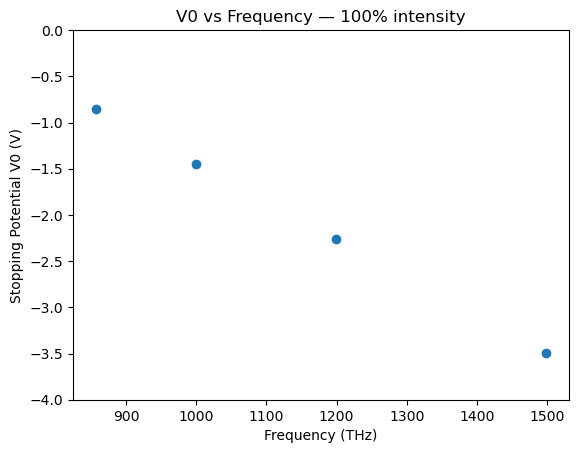

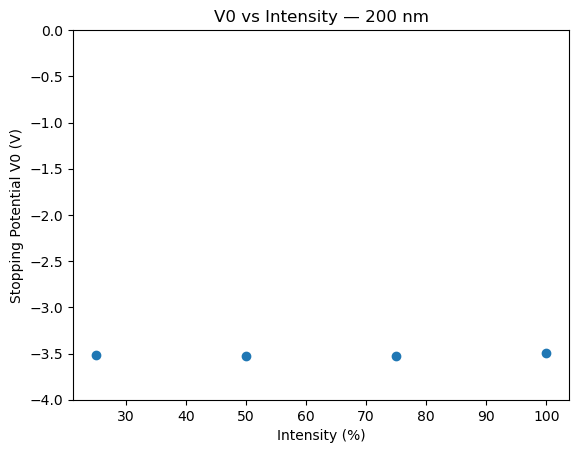

In [31]:
# --- Plot 1: V0 vs frequency at one intensity ---
mask = (data['intensity (percent)'] == 100)
one_intensity = data[mask]

plt.figure()
plt.scatter(one_intensity['frequency (THz)'], one_intensity['V0'])
plt.xlabel('Frequency (THz)')
plt.ylabel('Stopping Potential V0 (V)')
plt.title('V0 vs Frequency \u2014 100% intensity')
plt.ylim(-4,0)
plt.show()

# --- Plot 2: V0 vs intensity at one wavelength ---
one_wavelength = data[data['wavelength (nm)'] == 200]

plt.figure()
plt.scatter(one_wavelength['intensity (percent)'], one_wavelength['V0'])
plt.xlabel('Intensity (%)')
plt.ylabel('Stopping Potential V0 (V)')
plt.ylim(-4,0)

plt.title('V0 vs Intensity \u2014 200 nm')
plt.show()

### 3C — Visualizing All Data with Color-Coded Plots

`5 points`

*[Draft placeholder — needs instructor review]*

The single-filter plots above only show one slice of the data at a time. To see the full picture, use a `for` loop to overlay multiple datasets on the same axes.

**Task:** Create two side-by-side plots:

1. **Left:** $V_0$ vs. frequency, with one color per intensity.
2. **Right:** $V_0$ vs. intensity, with one color per wavelength.

Use `plt.subplots(1, 2)` to create a figure with two axes. Inside a `for` loop, filter the DataFrame and call `ax.scatter()` with a `label` argument, then call `ax.legend()` after the loop.

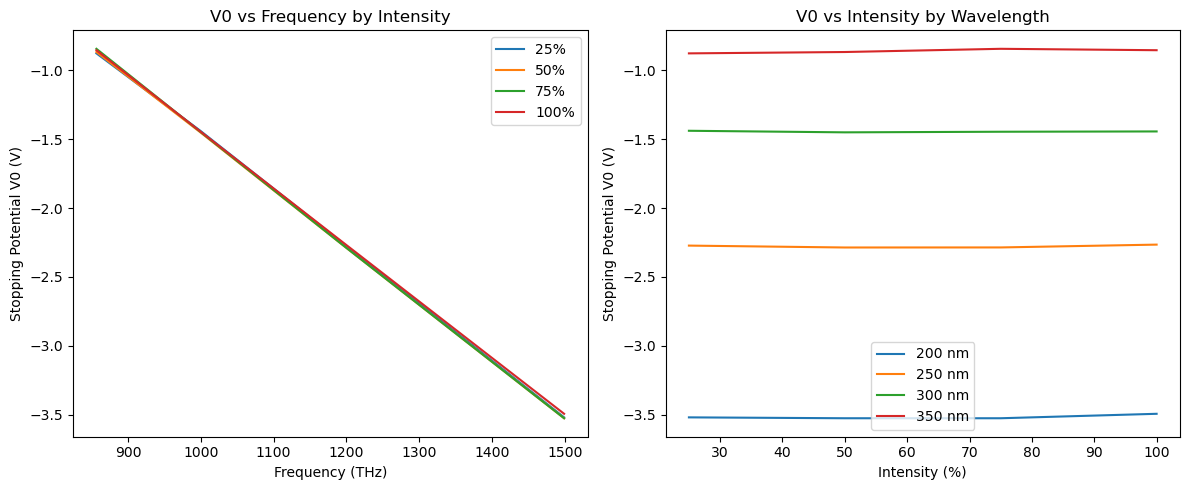

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: V0 vs frequency, colored by intensity ---
for intens in [25, 50, 75, 100]:
    subset = data[data['intensity (percent)'] == intens]
    ax1.plot(subset['frequency (THz)'], subset['V0'], label=f'{intens}%')7

ax1.set_xlabel('Frequency (THz)')
ax1.set_ylabel('Stopping Potential V0 (V)')
ax1.set_title('V0 vs Frequency by Intensity')
ax1.legend()

# --- Right plot: V0 vs intensity, colored by wavelength ---
for wave in [200, 250, 300, 350]:
    subset = data[data['wavelength (nm)'] == wave]
    ax2.plot(subset['intensity (percent)'], subset['V0'], label=f'{wave} nm')

ax2.set_xlabel('Intensity (%)')
ax2.set_ylabel('Stopping Potential V0 (V)')
ax2.set_title('V0 vs Intensity by Wavelength')
ax2.legend()

plt.tight_layout()
plt.show()

## Question 3

`10 points`

a) Based on your plots, how much does the stopping potential (i.e., the maximum electron kinetic energy) depend on the **frequency** of light?

b) How much does the stopping potential depend on the **intensity** of light?

c) Is your result for (b) strange? What does it suggest about the interaction between light and electrons?

---

# Part 4 — Extracting a Mysterious Physical Constant

By now we have come to the strange realization that increasing the energy density of the light does not increase the kinetic energy of the emitted electrons if we don’t change the wavelength.

This strongly suggests that the wavelength of light controls the energy that light imparts to electrons, but not the intensity. This makes no sense classically, where light is regarded as a continuous wave.

These results strongly suggest that light is **quantized** — that discrete interactions between particles of light and single electrons determine the emission energies. Otherwise, if light were continuous, we ought to see the stopping potential change with intensity.

Einstein’s photoelectric equation predicts:

$$
-eV_0 = h f - \phi
$$

where $h$ is a proportionality constant (which we will determine), $-e$ is the charge of one electron, $f$ is frequency, and $\phi$ is the work function of the metal.

This is a linear equation in $f$. So if we plot $V_0$ vs. $f$ and fit a line, we can extract $h$ and $\phi$ from the slope and intercept.

### 4A — Linear Fit of $V_0$ vs. Frequency

`5 points`

Since the stopping potential does not depend on intensity (as you discovered in Part 3), we can average $V_0$ across intensities for each wavelength to get a cleaner dataset.

Plot $V_0$ as a function of frequency and fit a straight line $V_0 = mf + b$.

Be careful with units! Your frequency column is in THz.

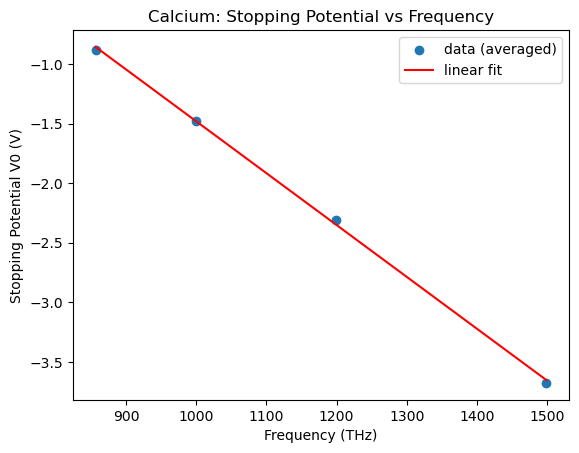

slope     = -4.354234e-03 V/THz
intercept = 2.8737 V


In [19]:
# Average V0 across intensities for each wavelength
avg_data = data.groupby('wavelength (nm)')['V0'].mean().reset_index()
avg_data['frequency (THz)'] = wavelength_nm_to_thz(avg_data['wavelength (nm)'])

f_thz = avg_data['frequency (THz)'].to_numpy()
V0_avg = avg_data['V0'].to_numpy()

# Linear fit
slope, intercept = linear_fit(f_thz, V0_avg)
V0_fit = slope * f_thz + intercept

# Plot
plt.figure()
plt.scatter(f_thz, V0_avg, label='data (averaged)')
plt.plot(f_thz, V0_fit, color='red', label='linear fit')
plt.xlabel('Frequency (THz)')
plt.ylabel('Stopping Potential V0 (V)')
plt.title('Calcium: Stopping Potential vs Frequency')
plt.legend()
plt.show()

print(f'slope     = {slope:.6e} V/THz')
print(f'intercept = {intercept:.4f} V')

### 4B — Determining Planck’s Constant from the Slope

`5 points`

From the photoelectric equation:

$$
V_0 = \frac{h}{e} f - \frac{\phi}{e}
$$

the slope is $m = h/e$, so $h = m \cdot e$.

**Watch your units.** Your slope has units of V/THz. To get $h$ in J·s, you need frequency in Hz:

$$
m \;(\text{V/THz}) \times 10^{-12} \;(\text{THz/Hz}) = m' \;(\text{V/Hz})
$$

Then $h = m' \cdot e$ because a volt is J/C and $e$ is in coulombs.

Compare your result to the accepted value of $h = 6.626 \times 10^{-34}$ J·s.

In [20]:
from scipy.constants import e as elementary_charge

# Convert slope from V/THz to V/Hz
slope_per_hz = slope * 1e-12   # V/THz * (1 THz / 1e12 Hz) = V/Hz

# h = slope * e
h_exp = slope_per_hz * elementary_charge

print(f'Experimental h = {h_exp:.4e} J\u00b7s')
print(f'Accepted h     = {Planck:.4e} J\u00b7s')
print(f'Percent error  = {abs(h_exp - Planck) / Planck * 100:.1f}%')

Experimental h = -6.9763e-34 J·s
Accepted h     = 6.6261e-34 J·s
Percent error  = 205.3%


### 4C — Work Function and Cutoff Frequency

`5 points`

From the intercept:

$$
b = -\frac{\phi}{e} \quad \Rightarrow \quad \phi = -b \cdot e
$$

The cutoff frequency $f_c$ is the frequency below which no electrons are emitted ($V_0 = 0$):

$$
0 = m f_c + b \quad \Rightarrow \quad f_c = -b/m
$$

Compute the work function $\phi$ (in J and eV), the cutoff frequency (in Hz), and the cutoff wavelength (in nm).

In [21]:
# Work function
phi_exp = -intercept * elementary_charge
print(f'Work function phi = {phi_exp:.4e} J')
print(f'Work function phi = {phi_exp / elementary_charge:.4f} eV')

# Cutoff frequency and wavelength
f_c_thz = -intercept / slope
f_c_hz = f_c_thz * 1e12
lambda_c_nm = speed_of_light / f_c_hz * 1e9

print(f'\nCutoff frequency  = {f_c_thz:.2f} THz')
print(f'Cutoff frequency  = {f_c_hz:.4e} Hz')
print(f'Cutoff wavelength = {lambda_c_nm:.1f} nm')

Work function phi = -4.6041e-19 J
Work function phi = -2.8737 eV

Cutoff frequency  = 659.97 THz
Cutoff frequency  = 6.5997e+14 Hz
Cutoff wavelength = 454.2 nm


## Question 4

`10 points`

a) Explain how the slope of your $V_0$ vs. frequency plot is related to Planck’s constant. Why must you use frequency in Hz (rather than THz) for $h$ to have units of J·s?

b) The intercept of the fitted line is negative. Explain why this must be the case, and interpret the intercept in terms of the work function. Using your fitted cutoff frequency $f_c$, explain why the condition $hf < \phi$ implies that increasing intensity cannot produce electron emission below the cutoff.

c) Compare your experimental value of $h$ to the accepted value. Give one plausible experimental reason and one plausible analysis reason for any discrepancy.

---

## Final Reflection

`10 points`

1. Explain in your own words how the photoelectric effect is evidence of light quantization. In particular, why is the observation that stopping potential depends on frequency but *not* on intensity inconsistent with classical wave theory?

2. Consider how **abstraction** helped you in this lab. You started by writing loose code for one dataset, then packaged it into functions, then used loops to apply those functions to many datasets. How does this approach help you write reusable, less error-prone programs?

3. What was most difficult about this assignment for you? What would help you improve this skill?

4. *(If you are involved in undergraduate research)* How could you use what you learned in this lab in your research? Give a concrete example.